In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
drive.mount("/content/drive", force_remount=True)
folder = "/content/drive/My Drive/Colab Notebooks/Цифровая обработка сигналов/"

Mounted at /content/drive


# 1. EKF

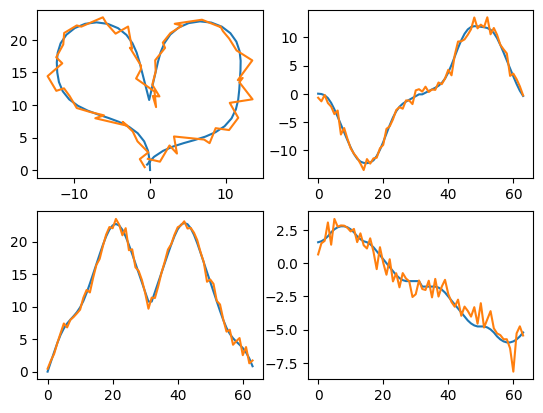

In [ ]:
# радиусы колес (рад)
W_L = 1.5
W_R = 1

# колесная база робота
B = 2

# шаг дискретизации
T = 1

# угловые скорости (рад/с) левого и правого колес
# в дискретные моменты времени kT, где k индекс массива
u_L = np.array([
    0.9, 0.8, 0.7, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4,
    1.3, 1.2, 1.1, 1.2, 1.3, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.3, 1.2, 1.1,
    1, 1, 1, 1,
    0.55,
    -1, -1, -1, -1,
    -0.9, -0.8, -0.7, -0.6, -0.6, -0.6, -0.6, -0.6, -0.6, -0.6, -0.7, -0.8, -0.9,
    -1, -1,
    -0.9, -0.8, -0.7, -0.6, -0.7, -0.8, -0.9, -1, -1.1, -1.2, -1.3, -1.4,
])
u_R = np.array([
    1.65, 1.8, 1.95, 2.1, 1.95, 1.8, 1.65, 1.5, 1.35, 1.2, 1.05, 0.9,
    1.05, 1.2, 1.35, 1.2, 1.05, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 1.05, 1.2, 1.35,
    1.5, 1.5, 1.5, 1.5,
    -0.825,
    -1.5, -1.5, -1.5, -1.5,
    -1.65, -1.8, -1.95, -2.1, -2.1, -2.1, -2.1, -2.1, -2.1, -2.1, -1.95, -1.8, -1.65,
    -1.5, -1.5,
    -1.65, -1.8, -1.95, -2.1, -1.95, -1.8, -1.65, -1.5, -1.35, -1.2, -1.05, -0.9,
])

# линейные скорости (рад/с) колес
s_L = W_L * u_L
s_R = W_R * u_R

# скорость передвижения (рад/с) робота
s_t = 0.5 * (s_L + s_R)

# скорость вращения (рад/с)
s_r = (s_R - s_L) / (2 * B)

# истинные показатели, начиная с известной стартовой позиции (x, y, r)
Y = np.array([
    [0],
    [0],
    [np.pi / 2],
])
for k in range(len(u_L)):
    Y_column = np.array([
        [Y[0, k] + T * s_t[k] * np.cos(Y[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(Y[2, k])],
        [Y[1, k] + T * s_t[k] * np.sin(Y[2, k]) + 0.5 * T * T * s_t[k] * s_r[k] * np.cos(Y[2, k])],
        [Y[2, k] + T * s_r[k]],
    ])
    Y = np.append(Y, Y_column, axis=1)

# дисперсии w_x, w_y, w_r
D_wx = 0.8
D_wy = 0.6
D_wr = 0.8
R = np.array([
    [D_wx, 0, 0],
    [0, D_wy, 0],
    [0, 0, D_wr],
])

# шум
noise = np.array([
    np.random.normal(loc=0, scale=np.sqrt(D_wx), size=Y[0, :].shape),
    np.random.normal(loc=0, scale=np.sqrt(D_wy), size=Y[1, :].shape),
    np.random.normal(loc=0, scale=np.sqrt(D_wr), size=Y[2, :].shape),
])
# наблюдения робота - собственные x, y, r
Z = Y + noise


figure, axis = plt.subplots(2, 2)

axis[0, 0].plot(Y[0, :], Y[1, :])
axis[0, 0].plot(Z[0, :], Z[1, :])

axis[0, 1].plot(Y[0, :])
axis[0, 1].plot(Z[0, :])

axis[1, 0].plot(Y[1, :])
axis[1, 0].plot(Z[1, :])

axis[1, 1].plot(Y[2, :])
axis[1, 1].plot(Z[2, :])

plt.show()

X = np.array([
    [0],
    [0],
    [np.pi / 2],
])

P = [
    np.array([
        [0.1, 0, 0],
        [0, 0.1, 0],
        [0, 0, 0.1],
    ]),
]
def f(X: np.array, k: int) -> np.array:
    return np.array([
        [X[0, k] + T * s_t[k] * np.cos(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(X[2, k])],
        [X[1, k] + T * s_t[k] * np.sin(X[2, k]) + 0.5 * T * T * s_t[k] * s_r[k] * np.cos(X[2, k])],
        [X[2, k] + T * s_r[k]],
    ])

def F_X(X: np.array, k: int) -> np.array:
    return np.array([
        [1, 0, df1dr(X, k)],
        [0, 1, df2dr(X, k)],
        [0, 0, 1],
    ])

def df1dr(X: np.array, k: int) -> np.array:
    return -T * s_t[k] * np.sin(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.cos(X[2, k])

def df2dr(X: np.array, k: int) -> np.array:
    return T * s_t[k] * np.cos(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(X[2, k])

def h(X: np.array) -> np.array:
    return np.array([
        [X[0, 0]],
        [X[1, 0]],
        [X[2, 0]],
    ])

def H_X() -> np.array:
    return np.eye(3)

# EKF
for k in range(1, len(u_L)):
    # прогноз
    X_predicted = f(X, k - 1)
    P_predicted = F_X(X, k - 1) @ P[k - 1] @ F_X(X, k - 1).T

    # коррекция
    S = H_X() @ P_predicted @ H_X().T + R
    K = P_predicted @ H_X().T @ np.linalg.inv(S)
    X = np.append(
        X,
        X_predicted + K @ (Z[:, [k]] - h(X_predicted)),
        axis=1
    )
    P.append(P_predicted - K @ S @ K.T)

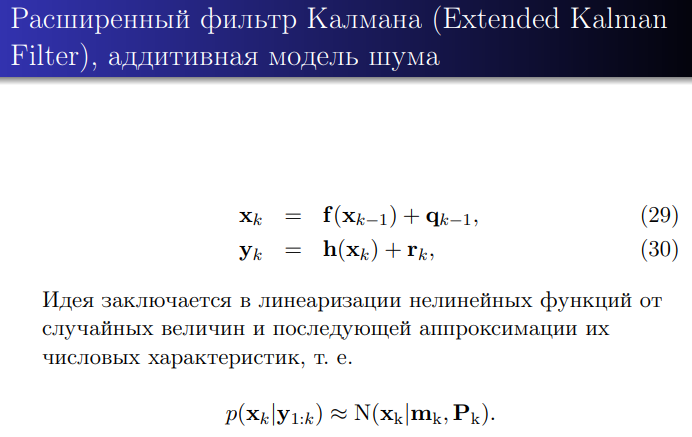

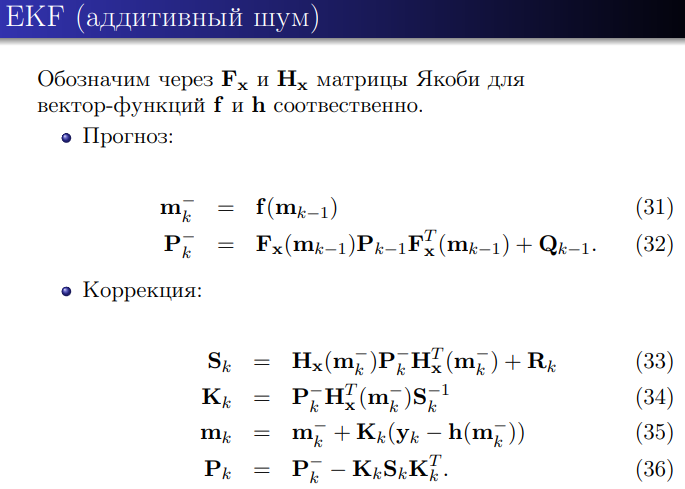

$X_{k}=(x_{k},y_{k},r_{k})$ - вектор-столбец

$X_{k+1}=f(X_{k})$

$f(X_{k}):$

$x[k+1]=x[k]+Ts_{t}[k]cos(r[k])-\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]sin(r[k])$

$y[k+1]=y[k]+Ts_{t}[k]sin(r[k])+\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]cos(r[k])$

$r[k+1]=r[k]+Ts_{r}[k]$

$F_{X}:$

$\frac{df_{1}(X_{k})}{dx}=1$;
$\frac{df_{1}(X_{k})}{dy}=0$;
$\frac{df_{1}(X_{k})}{dr}=-Ts_{t}sin(r[k])-\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]cos(r[k])$;

$\frac{df_{2}(X_{k})}{dx}=0$;
$\frac{df_{2}(X_{k})}{dy}=1$;
$\frac{df_{2}(X_{k})}{dr}=Ts_{t}[k]cos(r[k])-\frac{1}{2}T^{2}s_{t}[k]s_{r}[k]sin(r[k])$;

$\frac{df_{3}(X_{k})}{dx}=0$;
$\frac{df_{3}(X_{k})}{dy}=0$;
$\frac{df_{3}(X_{k})}{dr}=1$;

$h(X_{k}):$

$h(x[k])=x[k]$

$h(y[k])=y[k]$

$h(r[k])=r[k]$

$H_{X}:$

$\frac{dh_{1}(X_{k})}{dx}=1$;
$\frac{dh_{1}(X_{k})}{dy}=0$;
$\frac{dh_{1}(X_{k})}{dr}=0$;

$\frac{dh_{2}(X_{k})}{dx}=0$;
$\frac{dh_{2}(X_{k})}{dy}=1$;
$\frac{dh_{2}(X_{k})}{dr}=0$;

$\frac{dh_{3}(X_{k})}{dx}=0$;
$\frac{dh_{3}(X_{k})}{dy}=0$;
$\frac{dh_{3}(X_{k})}{dr}=1$;

$W=(w_{x},w_{y},w_{r})$ - вектор-столбец

$R:$

$(D_{wx} \space 0 \space 0)$

$(0 \space D_{wy} \space 0)$

$(0 \space 0 \space D_{wr})$

In [ ]:
def f(X: np.array, k: int) -> np.array:
    return np.array([
        [X[0, k] + T * s_t[k] * np.cos(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(X[2, k])],
        [X[1, k] + T * s_t[k] * np.sin(X[2, k]) + 0.5 * T * T * s_t[k] * s_r[k] * np.cos(X[2, k])],
        [X[2, k] + T * s_r[k]],
    ])

def F_X(X: np.array, k: int) -> np.array:
    return np.array([
        [1, 0, df1dr(X, k)],
        [0, 1, df2dr(X, k)],
        [0, 0, 1],
    ])

def df1dr(X: np.array, k: int) -> np.array:
    return -T * s_t[k] * np.sin(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.cos(X[2, k])

def df2dr(X: np.array, k: int) -> np.array:
    return T * s_t[k] * np.cos(X[2, k]) - 0.5 * T * T * s_t[k] * s_r[k] * np.sin(X[2, k])

def h(X: np.array) -> np.array:
    return np.array([
        [X[0, 0]],
        [X[1, 0]],
        [X[2, 0]],
    ])

def H_X() -> np.array:
    return np.eye(3)

In [ ]:
X = np.array([
    [0],
    [0],
    [np.pi / 2],
])

P = [
    np.array([
        [0.1, 0, 0],
        [0, 0.1, 0],
        [0, 0, 0.1],
    ]),
]

# EKF
for k in range(1, len(u_L)):
    # прогноз
    X_predicted = f(X, k - 1)
    P_predicted = F_X(X, k - 1) @ P[k - 1] @ F_X(X, k - 1).T

    # коррекция
    S = H_X() @ P_predicted @ H_X().T + R
    K = P_predicted @ H_X().T @ np.linalg.inv(S)
    X = np.append(
        X,
        X_predicted + K @ (Z[:, [k]] - h(X_predicted)),
        axis=1
    )
    P.append(P_predicted - K @ S @ K.T)

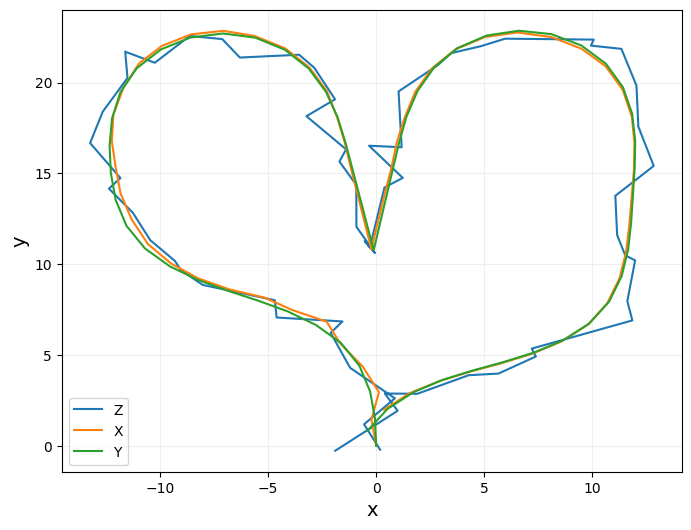

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(Z[0, :], Z[1, :], label="Z")
plt.plot(X[0, :], X[1, :], label="X")
plt.plot(Y[0, :], Y[1, :], label="Y")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# 2. EKF and UKF

In [ ]:
odometry_and_sensor_data = pd.read_csv(
    folder + "sensor_data_ekf.dat", sep=" ", header=None
)
print(odometry_and_sensor_data.head(6))

landmarks = pd.read_csv(
    folder + "landmarks.dat", sep=" ", header=None
)
print(landmarks.head(100))

          0         1         2         3
0  ODOMETRY  0.101374  0.099625  0.000862
1    SENSOR  1.000000  2.297253  0.353957
2    SENSOR  2.000000  4.018257  1.515074
3  ODOMETRY  0.101823  0.099725 -0.000207
4    SENSOR  1.000000  1.968467  0.276209
5    SENSOR  2.000000  3.879867  1.403931
   0   1  2
0  1   2  1
1  2   0  4
2  3   2  7
3  4   9  2
4  5  10  5
5  6   9  8
6  7   5  5
7  8   5  3
8  9   5  9


In [ ]:
mask = odometry_and_sensor_data[0] == "ODOMETRY"
odometry_data = odometry_and_sensor_data.loc[mask]
print(odometry_data.head())

           0         1         2         3
0   ODOMETRY  0.101374  0.099625  0.000862
3   ODOMETRY  0.101823  0.099725 -0.000207
6   ODOMETRY  0.100902  0.099758 -0.000382
9   ODOMETRY  0.099765  0.099799 -0.000208
12  ODOMETRY  0.098802  0.100360 -0.001229


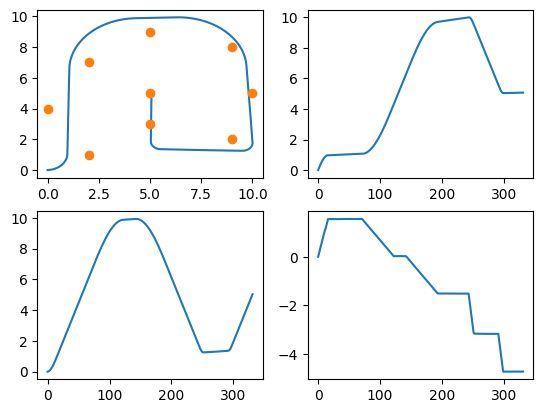

In [ ]:
# одометрия
Δ = odometry_data.drop(0, axis=1).to_numpy().T

# истинные показатели, начиная с известной стартовой позиции (x, y, θ)
Y = np.array([
    [0],
    [0],
    [0],
])
for t in range(Δ.shape[1]):
    Y_column = np.array([
        [Y[0, t] + Δ[1, t] * np.cos(Y[2, t] + Δ[0, t])],
        [Y[1, t] + Δ[1, t] * np.sin(Y[2, t] + Δ[0, t])],
        [Y[2, t] + Δ[0, t] + Δ[2, t]],
    ])
    Y = np.append(Y, Y_column, axis=1)

# шум процесса, дисперсии e_x, e_y, e_θ
D_ex = 0.2
D_ey = 0.2
D_eθ = 0.2
Q = np.array([
    [D_ex, 0, 0],
    [0, D_ey, 0],
    [0, 0, D_eθ],
])

# ошибка измерения, дисперсии расстояния и угла
D_r = 0.2
# to add angle:
# D_θ = 0.2

# наблюдения робота - переменное количество известных ориентиров
Z = []
sensor_data_block = np.array([[], [], []])
for i, row in odometry_and_sensor_data.iterrows():
    if row[0] == "ODOMETRY":
        Z.append(sensor_data_block)
        sensor_data_block = np.array([[], [], []])
        continue
    sensor_data_block = np.append(
        sensor_data_block,
        np.array([
            [row[1]],
            [row[2]],
            [row[3]],
        ]),
        axis=1,
    )
    if i == odometry_and_sensor_data.shape[0] - 1:
        Z.append(sensor_data_block)


figure, axis = plt.subplots(2, 2)

axis[0, 0].plot(Y[0, :], Y[1, :])
axis[0, 0].plot(landmarks[1], landmarks[2], 'o')

axis[0, 1].plot(Y[0, :])

axis[1, 0].plot(Y[1, :])

axis[1, 1].plot(Y[2, :])

plt.show()

In [ ]:
def f(X: np.array, t: int) -> np.array:
    return np.array([
        [X[0, t] + Δ[1, t] * np.cos(X[2, t] + Δ[0, t])],
        [X[1, t] + Δ[1, t] * np.sin(X[2, t] + Δ[0, t])],
        [X[2, t] + Δ[0, t] + Δ[2, t]],
    ])

def F_X(X: np.array, t: int) -> np.array:
    return np.array([
        [1, 0, df1dθ(X, t)],
        [0, 1, df2dθ(X, t)],
        [0, 0, 1],
    ])

def df1dθ(X: np.array, t: int) -> np.array:
    return -Δ[1, t] * np.sin(X[2, t] + Δ[0, t])

def df2dθ(X: np.array, t: int) -> np.array:
    return Δ[1, t] * np.cos(X[2, t] + Δ[0, t])

def F_Q() -> np.array:
    return np.eye(3)

def h(X: np.array, landmarks_ids: list[int]) -> np.array:
    r = landmarks_ids[0] - 1
    h = np.array([
        [np.sqrt(np.power(X[0, 0] - landmarks[1][r], 2) + np.power(X[1, 0] - landmarks[2][r], 2))],
    ])
    for i in range(1, len(landmarks_ids)):
        r = landmarks_ids[i] - 1
        h_row_block = np.array([
            [np.sqrt(np.power(X[0, 0] - landmarks[1][r], 2) + np.power(X[1, 0] - landmarks[2][r], 2))],
        ])
        h = np.vstack([h, h_row_block])
    return h

def H_X(X: np.array, landmarks_ids: list[int]) -> np.array:
    H_X = np.array([
        [dh1dx(X, landmarks_ids[0]), dh1dy(X, landmarks_ids[0]), 0],
    ])
    for i in range(1, len(landmarks_ids)):
        H_X_row_block = np.array([
            [dh1dx(X, landmarks_ids[i]), dh1dy(X, landmarks_ids[i]), 0],
        ])
        H_X = np.vstack([H_X, H_X_row_block])
    return H_X

def dh1dx(X: np.array, landmark_id: int) -> np.array:
    r = landmark_id - 1
    return (X[0, 0] - landmarks[1][r]) / np.sqrt(np.power(X[0, 0] - landmarks[1][r], 2) + np.power(X[1, 0] - landmarks[2][r], 2))

def dh1dy(X: np.array, landmark_id: int) -> np.array:
    r = landmark_id - 1
    return (X[1, 0] - landmarks[2][r]) / np.sqrt(np.power(X[0, 0] - landmarks[1][r], 2) + np.power(X[1, 0] - landmarks[2][r], 2))

def dh2dx(X: np.array, landmark_id: int) -> np.array:
    r = landmark_id - 1
    return (landmarks[2][r] - X[1, 0]) / (np.power(X[0, 0] - landmarks[1][r], 2) + np.power(X[1, 0] - landmarks[2][r], 2))

def dh2dy(X: np.array, landmark_id: int) -> np.array:
    r = landmark_id - 1
    return (X[0, 0] - landmarks[1][r]) / (np.power(X[0, 0] - landmarks[1][r], 2) + np.power(X[1, 0] - landmarks[2][r], 2))

In [ ]:
X = np.array([
    [0],
    [0],
    [0],
])

P = [
    np.array([
        [0.1, 0, 0],
        [0, 0.1, 0],
        [0, 0, 0.1],
    ]),
]

# EKF
for t in range(1, Δ.shape[1]):
    landmarks_ids = [*map(int, Z[t][0, :])]
    # to add angle change index:
    measurements = Z[t][1: 2, :].reshape((len(landmarks_ids), 1), order="F")

    # прогноз
    X_predicted = f(X, t - 1)
    P_predicted = F_X(X, t - 1) @ P[t - 1] @ F_X(X, t - 1).T + F_Q() @ Q @ F_Q().T

    # коррекция
    # to add angle:
    # R_block = np.array([
    #     [D_r, 0],
    #     [0, D_θ],
    # ])
    # R = scipy.linalg.block_diag(*[R_block for i in range(len(landmarks_ids))])
    R = np.diag(np.full(len(landmarks_ids), D_r))
    S = H_X(X_predicted, landmarks_ids) @ P_predicted @ H_X(X_predicted, landmarks_ids).T + R
    K = P_predicted @ H_X(X_predicted, landmarks_ids).T @ np.linalg.inv(S)
    X = np.append(
        X,
        X_predicted + K @ (measurements - h(X_predicted, landmarks_ids)),
        axis=1,
    )
    P.append(P_predicted - K @ S @ K.T)

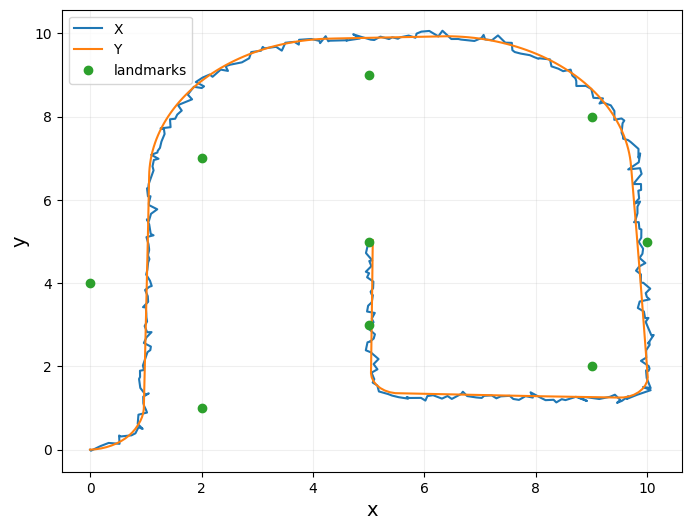

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(X[0, :], X[1, :], label="X")
plt.plot(Y[0, :], Y[1, :], label="Y")
plt.plot(landmarks[1], landmarks[2], 'o', label="landmarks")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

https://groups.seas.harvard.edu/courses/cs281/papers/unscented.pdf

In [ ]:
def f(x: np.array, t: int) -> np.array:
    return np.array([
        x[0] + Δ[1, t] * np.cos(x[2] + Δ[0, t]),
        x[1] + Δ[1, t] * np.sin(x[2] + Δ[0, t]),
        x[2] + Δ[0, t] + Δ[2, t],
    ])

def h(x: np.array, landmarks_ids: list[int]) -> np.array:
    r = landmarks_ids[0] - 1
    h = np.array([np.sqrt(np.power(x[0] - landmarks[1][r], 2) + np.power(x[1] - landmarks[2][r], 2))])
    for i in range(1, len(landmarks_ids)):
        r = landmarks_ids[i] - 1
        h = np.append(h, np.sqrt(np.power(x[0] - landmarks[1][r], 2) + np.power(x[1] - landmarks[2][r], 2)))
    return h

In [ ]:
X = np.array([
    [0],
    [0],
    [0],
])

P = [
    np.array([
        [0.1, 0, 0],
        [0, 0.1, 0],
        [0, 0, 0.1],
    ]),
]

# UKF
# инициализация параметров
α = 5e-2
κ = 0
β = 2
n = X.shape[0]
λ = α * α * (n + κ) - n
# весовые коэффициенты
W_m = np.array([1 / (2 * (n + λ))] * (2 * n + 1))
W_c = np.array([1 / (2 * (n + λ))] * (2 * n + 1))
W_m[0] = λ / (n + λ)
W_c[0] = λ / (n + λ) + (1 - α * α + β) # в статье β, в лекции β^2, но разницы будто нет
W_c = W_c[:, np.newaxis, np.newaxis]
for t in range(1, Δ.shape[1]):
    landmarks_ids = [*map(int, Z[t][0, :])]
    measurements = Z[t][1: 2, :].reshape((len(landmarks_ids), 1), order="F")

    # прогноз
    # генерация сигма-точек
    d = np.linalg.cholesky((n + λ) * P[t - 1])
    χ = np.hstack((X[:, [t - 1]], X[:, [t - 1]] + d, X[:, [t - 1]] - d))

    χ_predicted = np.apply_along_axis(lambda sigma_point: f(sigma_point, t - 1), 0, χ)

    X_predicted = np.sum(W_m * χ_predicted, axis=1)[:, np.newaxis]
    P_predicted = np.sum(
        W_c * (χ_predicted - X_predicted) @ (χ_predicted - X_predicted).T,
        axis=0,
    ) + Q

    # коррекция
    # генерация сигма-точек
    d = np.linalg.cholesky((n + λ) * P_predicted)
    χ = np.hstack((X_predicted, X_predicted + d, X_predicted - d))

    R = np.diag(np.full(len(landmarks_ids), D_r))

    Y_predicted = np.apply_along_axis(
        lambda sigma_point: h(sigma_point, landmarks_ids), 0, χ
    )

    μ = np.sum(W_m * Y_predicted, axis=1)[:, np.newaxis]

    S = np.sum(
        W_c * (Y_predicted - μ) @ (Y_predicted - μ).T,
        axis=0,
    ) + R

    C = np.sum(
        W_c * (χ - X_predicted) @ (Y_predicted - μ).T,
        axis=0,
    )

    K = C @ np.linalg.inv(S)

    X = np.append(
        X,
        X_predicted + K @ (measurements - μ),
        axis=1,
    )
    P.append(P_predicted - K @ S @ K.T)

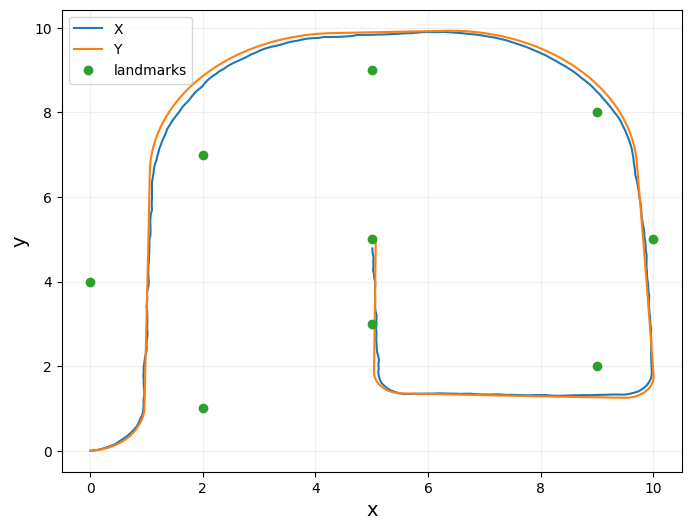

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(X[0, :], X[1, :], label="X")
plt.plot(Y[0, :], Y[1, :], label="Y")
plt.plot(landmarks[1], landmarks[2], 'o', label="landmarks")
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# 3. RBPF (не осилил)

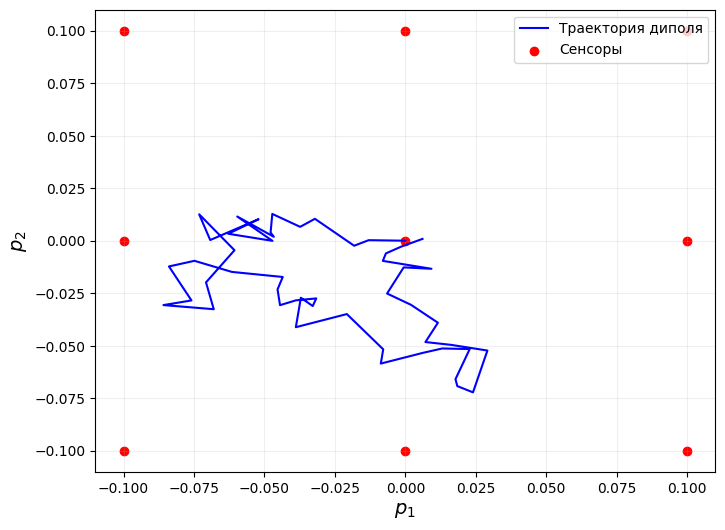

In [ ]:
# число сенсоров
L_1 = 3
L_2 = 3
L = L_1 * L_2

# границы сетки расположения сенсоров
L_xmin = -0.1
L_xmax = 0.1
L_ymin = -0.1
L_ymax = 0.1

# высота сенсоров над плоскостью
h = 3.0

# координаты сенсоров
r_x, r_y = np.meshgrid(
    np.linspace(L_xmin, L_xmax, L_1),
    np.linspace(L_ymin, L_ymax, L_2),
)
r_x = r_x.reshape(1, L)
r_y = r_y.reshape(1, L)
r = np.array([[], [], []])
for i in range(L):
    r = np.append(
        r,
        np.array([r_x[0, [i]], r_y[0, [i]], [h]]),
        axis=1,
    )

# магнитная постоянная
μ_0 = 4 * np.pi * 1e-7

# шум положения
λ = 0.01
# шум дипольного момента
δ = 0.001
# матрица ковариаций аддитивного шума модели движения
C = np.diag([λ * λ, λ * λ, δ * δ, δ * δ])

# шум измерений
D_V = 1e-6
# матрица ковариаций аддитивного шума модели наблюдения
Γ = D_V * np.eye(L)

# число шагов
N = 50
# массив состояний, начиная с известной стартовой позиции (p1, p2, q1, q2)
Y = np.array([[0], [0], [0], [0]])
for i in range(N):
    w = np.random.multivariate_normal(np.zeros(Y.shape[0]), C)
    Y = np.append(
        Y,
        Y[:, [i]] + w.reshape((Y.shape[0], 1)),
        axis=1,
    )

def b(x: np.array, r: np.array) -> np.array:
    b = np.array([])
    for i in range(L):
        # сенсоры наблюдают только 3 координату магнитного поля
        numerator = x[2] * (r[1, [i]] - x[1]) - x[3] * (r[0, [i]] - x[0])
        denominator = ((r[0, [i]] - x[0])**2 + (r[1, [i]] - x[1])**2 + r[2, [i]]**2)**1.5
        b = np.append(b, (μ_0 / (4 * np.pi)) * numerator[0] / denominator[0])
    return b.reshape((L, 1))

# массив наблюдений
Z = np.array([[] for i in range(L)])
for i in range(N):
    v = np.random.multivariate_normal(np.zeros(L), Γ)
    Z = np.append(Z, b(Y[:, [i]], r) + v.reshape((L, 1)), axis=1)

plt.figure(figsize=(8, 6))
plt.plot(Y[0, :], Y[1, :], "b-", label="Траектория диполя")
plt.scatter(r[0, :], r[1, :], c="red", label="Сенсоры")
plt.xlabel("$p_1$", fontsize=14)
plt.ylabel("$p_2$", fontsize=14)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [ ]:
particles_number = 100

particles_p = np.random.normal(0, 1, (2, particles_number))
for k in range(N):
    particles_p += np.random.normal(0, λ, (2, particles_number))

[[ 4.26498415e-01 -7.20856263e-01  4.61599443e-01 -8.19138947e-01
   9.54965567e-02 -3.62347603e-01 -1.72989122e+00  1.26092786e+00
   7.45560490e-01  7.57851809e-01 -7.44549235e-02 -6.62111920e-01
  -6.50464984e-01  1.06061848e+00  2.31986719e-01 -1.23678947e+00
  -9.07080877e-01 -1.46572854e+00 -4.46852256e-01 -1.32416993e+00
  -1.55837769e+00 -1.03205304e+00  6.55760251e-01 -1.14105779e+00
  -1.24317375e+00  2.15847855e-01 -4.04101221e-01  3.65033883e-01
  -1.20782170e-01 -9.86512442e-01 -1.56370495e+00 -3.63274739e-01
   1.74381690e+00 -3.42991150e-01  3.53190577e-01 -1.00067195e-01
   1.18355176e+00  5.14240371e-01 -1.14002466e+00 -2.65856678e-02
   1.36033852e+00  3.29233334e-02 -1.85548695e+00 -1.11588370e+00
   7.56075762e-01 -8.90246526e-02  2.03455162e-01  8.77028276e-01
   5.46013700e-01  4.08729492e-01 -9.56299095e-01 -1.08942649e+00
   1.08784549e+00  4.71238426e-01 -2.41979652e-02  1.78871054e-01
   9.18022385e-01  1.94082488e+00  2.01416528e+00 -1.35272966e+00
  -6.13902

In [ ]:
def rbpf_tracking(y, r_j, h, N_particles, N_steps, lambda_, delta, sigma):
    L = r_j.shape[0]  # число датчиков
    mu_0 = 4 * np.pi * 1e-7

    # Инициализация частиц
    particles_p = np.random.normal(0, 1, (N_particles, 2))
    particles_q_mean = np.zeros((N_particles, 2))
    particles_q_cov = np.tile(np.eye(2), (N_particles, 1, 1))

    # Массивы для хранения результатов
    p_est = np.zeros((N_steps, 2))
    q_est = np.zeros((N_steps, 2))

    for k in range(N_steps):
        # Шаг предсказания (положение)
        particles_p += np.random.normal(0, lambda_, (N_particles, 2))

        # Шаг предсказания (дипольный момент)
        for i in range(N_particles):
            particles_q_cov[i] += delta**2 * np.eye(2)

        # Вычисление весов
        weights = np.zeros(N_particles)
        for i in range(N_particles):
            p = particles_p[i]
            G = np.zeros((L, 2))
            for j in range(L):
                rj1, rj2 = r_j[j, 0], r_j[j, 1]
                d = (rj1 - p[0])**2 + (rj2 - p[1])**2 + h**2
                G[j, 0] = (mu_0 / (4 * np.pi)) * (rj2 - p[1]) / (d**1.5)
                G[j, 1] = -(mu_0 / (4 * np.pi)) * (rj1 - p[0]) / (d**1.5)

            y_pred = G @ particles_q_mean[i]
            S = G @ particles_q_cov[i] @ G.T + sigma**2 * np.eye(L)
            try:
                weights[i] = multivariate_normal.pdf(y[k], mean=y_pred, cov=S)
            except:
                weights[i] = 0  # избегаем численных ошибок

        weights += 1e-10  # для избежания нулевых весов
        weights /= np.sum(weights)

        # Перевыборка
        indices = np.random.choice(N_particles, size=N_particles, p=weights)
        particles_p = particles_p[indices]
        particles_q_mean = particles_q_mean[indices]
        particles_q_cov = particles_q_cov[indices]

        # Обновление фильтра Калмана для каждой частицы
        for i in range(N_particles):
            p = particles_p[i]
            G = np.zeros((L, 2))
            for j in range(L):
                rj1, rj2 = r_j[j, 0], r_j[j, 1]
                d = (rj1 - p[0])**2 + (rj2 - p[1])**2 + h**2
                G[j, 0] = (mu_0 / (4 * np.pi)) * (rj2 - p[1]) / (d**1.5)
                G[j, 1] = -(mu_0 / (4 * np.pi)) * (rj1 - p[0]) / (d**1.5)

            S = G @ particles_q_cov[i] @ G.T + sigma**2 * np.eye(L)
            K = particles_q_cov[i] @ G.T @ np.linalg.inv(S)
            y_pred = G @ particles_q_mean[i]
            particles_q_mean[i] += K @ (y[k] - y_pred)
            particles_q_cov[i] = (np.eye(2) - K @ G) @ particles_q_cov[i]

        # Оценка состояния
        p_est[k] = np.mean(particles_p, axis=0)
        q_est[k] = np.mean(particles_q_mean, axis=0)

    return p_est, q_est

# 5. LSA

In [ ]:
# вычисление задержек через взаимную корреляционную функцию
# (мера схожести двух сигналов в зависимости от временного сдвига одного относительно другого)
def calculate_delay(signal, reference):
    correlation = np.correlate(signal, reference)
    max_lag = np.argmax(correlation)
    return max_lag / sampling_rate

# функция МНК для минимизации
def error_function(coordinates, n):
    x, y, z = coordinates
    errors = []
    for i in range(n):
        dx = x - speakers[i, 0]
        dy = y - speakers[i, 1]
        dz = z - speakers[i, 2]
        calculated_R = np.sqrt(dx * dx + dy * dy + dz * dz)
        errors.append(calculated_R - R[i])
    return np.sum(np.array(errors)**2)

In [ ]:
s = np.loadtxt(folder + "Transmitter.txt") # 4xN матрица сигналов
r = np.loadtxt(folder + "Receiver.txt") # 1xN вектор принятого сигнала

# координаты громкоговорителей
speakers = np.array([
    [0, 0, 10],
    [20, 0, 10],
    [20, 20, 10],
    [0, 20, 10]
])

sampling_rate = 100000 # частота дискретизации
v_sound = 1125 # скорость звука

T = [calculate_delay(r, s[i]) for i in range(len(speakers))] # задержки
R = [T_i * v_sound for T_i in T] # расстояния от микрофона до громкоговорителей

# начальное предположение
initial_guess = [10, 5, 5]
result = sp.optimize.minimize(
    error_function, initial_guess, len(speakers), method="L-BFGS-B"
)
x, y, z = map(float, result.x)
print(f"Координаты микрофона: ({x:.2f}, {y:.2f}, {z:.2f})")

Координаты микрофона: (8.00, 4.60, 5.76)
